In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
nltk.download('stopwords')
from nltk.corpus import stopwords

sns.set_theme(style="whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yostinaabera/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Load the news data

In [2]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")  # adjust filename
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


### Descriptive statistics on headlines

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


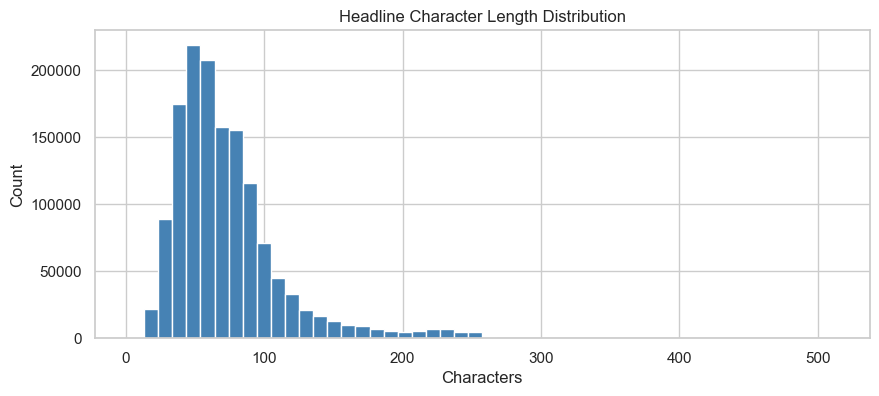

In [3]:
# Headline length
df['headline_length'] = df['headline'].astype(str).apply(len)

print(df['headline_length'].describe())

df['headline_length'].hist(bins=50, figsize=(10,4), color='steelblue')
plt.title("Headline Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

 ### Articles per publisher

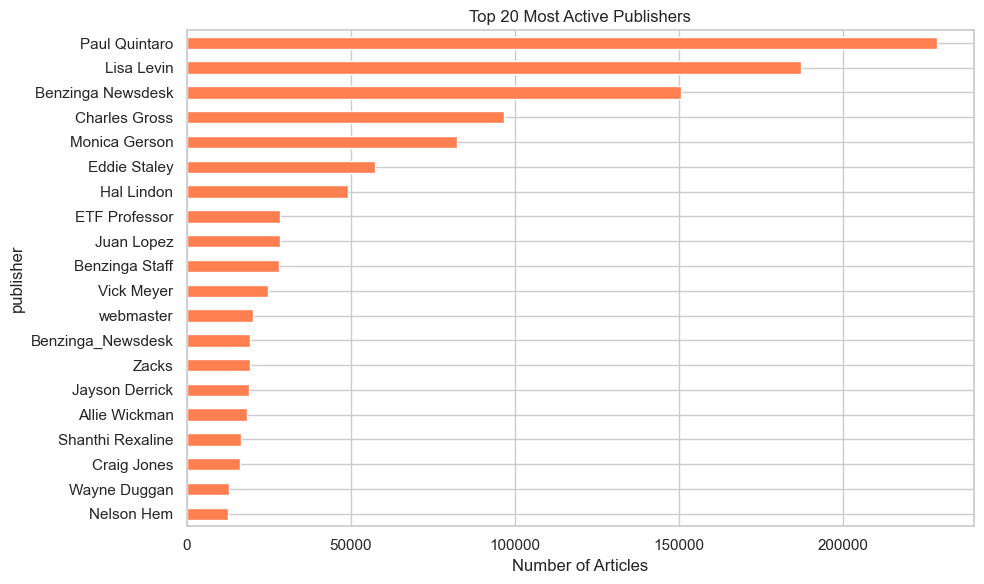

In [4]:
publisher_counts = df['publisher'].value_counts().head(20)

publisher_counts.plot(kind='barh', figsize=(10,6), color='coral')
plt.title("Top 20 Most Active Publishers")
plt.xlabel("Number of Articles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Publication date trends

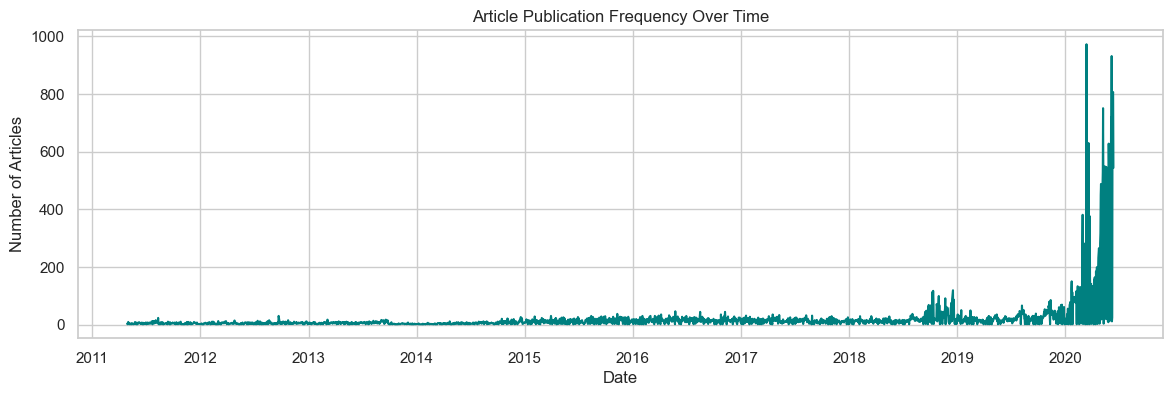

In [5]:
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')
df['date_only'] = df['date'].dt.date

articles_per_day = df.groupby('date_only').size()

articles_per_day.plot(figsize=(14,4), color='teal')
plt.title("Article Publication Frequency Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

###  Keyword/Topic Analysis with TF-IDF

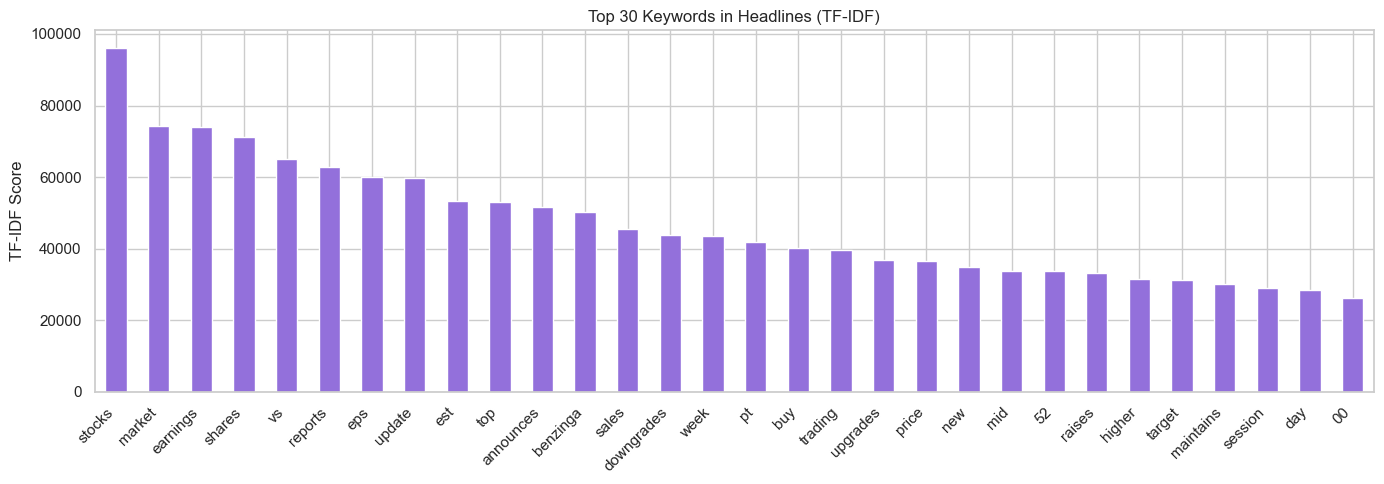

In [6]:
stop_words = list(stopwords.words('english'))

tfidf = TfidfVectorizer(max_features=30, stop_words=stop_words)
tfidf_matrix = tfidf.fit_transform(df['headline'].astype(str))

top_words = tfidf.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1

word_scores = pd.Series(scores, index=top_words).sort_values(ascending=False)

word_scores.plot(kind='bar', figsize=(14,5), color='mediumpurple')
plt.title("Top 30 Keywords in Headlines (TF-IDF)")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Publisher domain extraction

In [7]:
def extract_domain(publisher):
    match = re.search(r'@([\w.]+)', str(publisher))
    return match.group(1) if match else publisher

df['publisher_domain'] = df['publisher'].apply(extract_domain)
print(df['publisher_domain'].value_counts().head(15))

publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64
